# Compute And Plot Work/Lift (All Regions)

Python notebook translation of `matlab/entries/compute_and_plot_work_lift_all_regions.m`.

This notebook runs the translated all-regions analysis and reproduces the legacy stacked-bar visualization.

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'python'))

from translated_from_matlab.analysis.work_lift_all_regions import (
    apply_defaults,
    build_summary_table,
    run_work_lift_all_regions_analysis,
)

Reading control simulation: /scratch/gpfs/mbolot/results/GLOBALFV3/work_coarse_C3072_360x180/work_2020010300_2022011200.nc


/home/mbolot/.conda/envs/easyclim/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reading warming simulation: /scratch/gpfs/mbolot/results/GLOBALFV3/work_coarse_C3072_360x180_PLUS_4K_CO2_1270ppmv/work_2020010300_2022011800.nc

=== Spatial + Time Averaged Results ===
Region                 Simulation           work         lift           ke    lift/work    missing
global                 control          1.933528     1.372658     0.560870     0.709924          1
global                 warming          2.388109     1.720165     0.667944     0.720304         14
tropics                control          2.890790     2.043652     0.847138     0.706953          1
tropics                warming          3.546679     2.536555     1.010124     0.715192         14
maritime continent     control          5.682404     4.092441     1.589963     0.720195          1
maritime continent     warming          7.312827     5.310474     2.002353     0.726186         14
north. midlatitudes    control          1.295371     0.936146     0.359225     0.722686          1
north. midlatitudes    

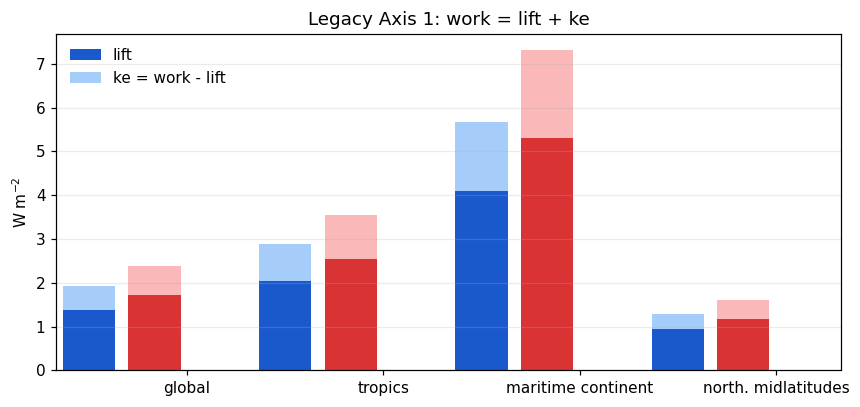

In [2]:
cfg = apply_defaults({
    'make_plots': True,
    'print_summary': True,
})

result = run_work_lift_all_regions_analysis({
    'control_file': cfg.control_file,
    'warming_file': cfg.warming_file,
    'regions': cfg.regions,
    'make_plots': cfg.make_plots,
    'print_summary': cfg.print_summary,
})

In [3]:
summary = build_summary_table(result)
summary

,region,simulation,work,lift,ke,lift_over_work,missing_steps
0,global,control,1.933528,1.372658,0.560870,0.709924,1
1,global,warming,2.388109,1.720165,0.667944,0.720304,14
2,tropics,control,2.890790,2.043652,0.847138,0.706953,1
3,tropics,warming,3.546679,2.536555,1.010124,0.715192,14
4,maritime continent,control,5.682404,4.092441,1.589963,0.720195,1
5,maritime continent,warming,7.312827,5.310474,2.002353,0.726186,14
6,north. midlatitudes,control,1.295371,0.936146,0.359225,0.722686,1
7,north. midlatitudes,warming,1.612710,1.181752,0.430959,0.732774,14


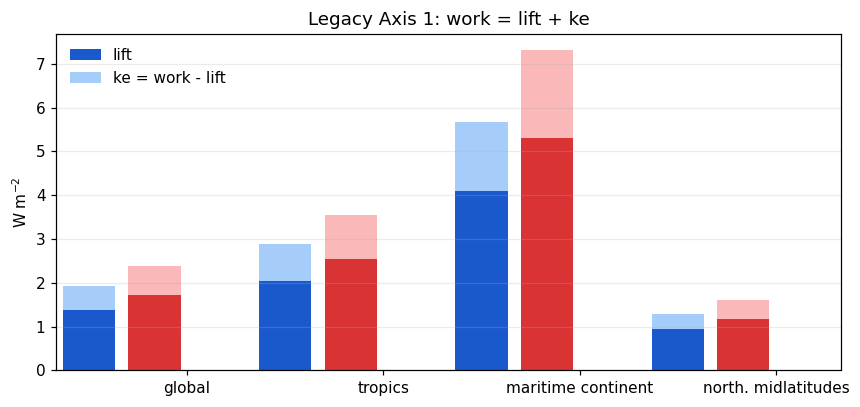

In [4]:
result.figure